- 知识点：
    - 宏观上知道一个智能模型从无到有：
        - 实现模型：
        - 数据集处理：
        - 训练模型：
        - 模型推理

# 1. LetNet网络

- 模块(Module)：
    - 层(Layer)
        - 运算层
            - 全连接运算-线性运算（分类器）
            - 卷积运算（图像特征抽取器）
        - 激活层
            - 修正线性单元
                - relu
                - ...
            - 池化层
                - 最值池化

In [2]:
import torch
class Lenet5(torch.nn.Module):

    def __init__(self):
        super(Lenet5, self).__init__()
        # 1. 定义5*5卷积层 1->6  5 * 5   padding=2   （28 * 28 -> 28 * 28)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv1 = torch.nn.Conv2d(
            in_channels=1,   # 输入图像的通道
            out_channels=6,  # 输出特征图的个数（通道）
            kernel_size=5,   # 卷积核大小
            # stride=1,        # 卷积核华东的步长step = stride
            padding=2,       # 补边
            # bias=True,       # 偏差 Y=WX+ b其中的b
        )
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2) # 2或者(2, 2)
        
        # 2. 定义5 * 5卷积 6->16 5 * 5， pandding=0(不补边) (14 * 14 -> 10 * 10)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)
        
        # 3. 定义5 * 5卷积16 -> 120  5 * 5, padding=0 (5 * 5 -> 1 * 1)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.conv3 = torch.nn.Conv2d(16, 120, 5)
        self.relu3 = torch.nn.ReLU()
        
        # 把120 * 1 *1 变成120长的向量
        
        # 4. 定义线性运算  120 -> 84
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.fc4 = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU()

        # 5. 定义线性运算 84 -> 10
        self.fc5 = torch.nn.Linear(84, 10)
        # 推理判断        
        

    def forward(self, x):
        # 实现运算
        x = self.conv1(x)    # 可调用对象
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        # x = torch.flatten(x)   # 把120 * 1 * 1的数组变成(1, 120)的向量(注意：批次不要被吃掉)
        x = x.view(1, 120)   # （N, ...）

        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        return x


# 2. 模拟实现推理

In [6]:
# 生成模拟数据（N，C，H， W）：批次数量， 通道，高度， 宽度 （1, 1, 28, 28）：随机
x = torch.randn(1, 1, 28, 28)
# 生成网络结构
model = Lenet5()
print(model)
print("-------------------------------")
# 推理
y = model(x)
print(y)
print("-------------------------------")
# 处理推理数据
p, c = torch.max(y, dim=1)   # 
print(p,c)
print("-------------------------------")
print(F"类别是：{c.detach().item()},概率是:{p.detach().item()}")

Lenet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (relu3): ReLU()
  (fc4): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU()
  (fc5): Linear(in_features=84, out_features=10, bias=True)
)
-------------------------------
tensor([[ 0.0237, -0.0418, -0.0404,  0.1025,  0.1451,  0.0924,  0.0677, -0.0580,
         -0.0247,  0.0280]], grad_fn=<AddmmBackward0>)
-------------------------------
tensor([0.1451], grad_fn=<MaxBackward0>) tensor([4])
-------------------------------
类别是：4,概率是:0.14510361850261688


In [ ]:
#举例子

# from transformers import AutoTokenizer, AutoModelForCausalLM
# import torch
# tokenizer = AutoTokenizer.from_pretrained(
#     r"D:\DeepSeek\DeepSeek-Coder-V2-Lite-Instruct", 
#     trust_remote_code=True
# )
# model = AutoModelForCausalLM.from_pretrained(
#     r"D:\DeepSeek\DeepSeek-Coder-V2-Lite-Instruct", 
#     trust_remote_code=True, 
#     torch_dtype=torch.bfloat16     # 混合精度：量化
# ).cuda()

# input_text = "使用C++写一个冒泡算法"
# inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# outputs = model.generate(**inputs, max_length=128)
# print(tokenizer.decode(outputs[0], skip_special_tokens=True))

# 3. 数据集加载

- 数据集的来源：
    - 各种框架中处理好的数据，直接使用。
        - scikit-learning机器学习的数据
        - torch中封装的数据集
    - 来自开源数据集
        - HuggingFace
        - ModelScope
        - github（小数据集）
    - 用户采集
        - 采集
        - 标注
        - 格式转换

```python
torchvision.datasets.MNIST(
    root: Union[str, Path],    # 目录
    train: bool = True,        # 训练或者验证集
    transform: Optional[Callable] = None,  # 加载的图像默认是PIL.Image（转换为张量）
    target_transform: Optional[Callable] = None,   # 标签的处理
    download: bool = False)  #是否存在（没有一定下载）
```

In [14]:
import torch
import torchvision

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)

ds_train = torchvision.datasets.MNIST(
    root="./mnist",
    train=True,
    transform=transform,
    download=False
)

# 查看训练集大小
print("训练集数量：", len(ds_train))

# 取第一张图片和标签
img, label = ds_train[4]
print("图片形状：", img.shape)  # 应该输出 torch.Size([1, 28, 28])
print("图片标签：", label)      # 输出 5 之类的数字

训练集数量： 60000
图片形状： torch.Size([1, 28, 28])
图片标签： 9


In [12]:
ds_valid = torchvision.datasets.MNIST(
    root="./mnist",
    train=False,
    transform=transform,
    download=True
)

# 查看验证集数量（应该是 10000）
print("验证集数量：", len(ds_valid))

# 取一张验证集图片
img, label = ds_valid[0]

#img = ds_valid[0][0]    # 取第一张图片
#label = ds_valid[0][1]  # 取第一张图片的标签

print("图片形状：", img.shape)
print("真实标签：", label)

验证集数量： 10000
图片形状： torch.Size([1, 28, 28])
真实标签： 7


In [17]:
ds_train[0][1]

5

In [18]:
ds_train[0][0].shape

torch.Size([1, 28, 28])

最终形状： (28, 28, 1)


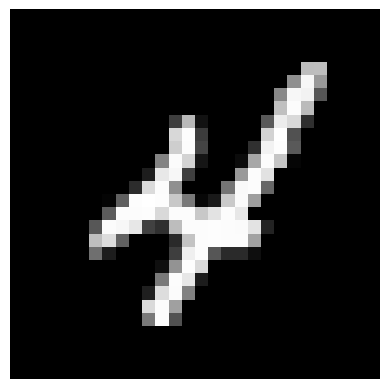

True

In [22]:
# 导入数值计算库，起别名 np（简写方便）
import numpy as np

# 导入画图库，用来显示图像，起别名 plt
import matplotlib.pyplot as plt

# ------------------- 第1步：拿到图像张量 -------------------
# 从训练集里拿第1张图片：ds_train[0] 是第1个样本，[0] 是图片数据
# 此时 x 的形状：torch.Size([1, 28, 28]) → 通道、高、宽
x = ds_train[0][0]  

# ------------------- 第2步：调整维度顺序 -------------------
# PyTorch 图像格式：通道在前 → [C, H, W]
# matplotlib 格式：通道在后 → [H, W, C]
# permute(1,2,0) 意思：把原来的第1、2、0维度重新排列
# 结果：[28, 28, 1]
x = x.permute(1, 2, 0)  

# ------------------- 第3步：张量转成普通数组 -------------------
# PyTorch 的张量 → 转成 numpy 数组（画图必须用数组）
x = x.numpy()  

# ------------------- 第4步：数值范围转换 -------------------
# 图像张量里的值是 0~1
# 真正的图片是 0~255，所以 ×255 还原成图片格式
x = x * 255

# 转成无符号8位整数（图片标准格式）
x = x.astype(np.uint8)  

# 打印最终形状 → (28, 28, 1)
print("最终形状：", x.shape)  

# ------------------- 第5步：显示图像 -------------------
# imshow：显示图像
# cmap="gray"：用灰度图显示（必须写 gray，不是 grey）
plt.imshow(x, cmap="gray")

# 关掉坐标轴，让图更好看
plt.axis("off")

# 弹出窗口显示图片
plt.show()

# ------------------- 第6步：保存图片到本地 -------------------
import cv2
# 把数组保存成 5.jpg 文件
cv2.imwrite(f"{ds_train[9][1]}.jpg", x)

In [27]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy
import cv2

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)

ds_train = torchvision.datasets.MNIST(
    root="./mnist",
    train=True,
    transform=transform,
    download=True
)
ds_valid = torchvision.datasets.MNIST(
    root="./mnist",
    train=False,
    transform=transform,
    download=True
)

def save_pic(ds, idx):
    x = ds[idx][0]    # 重点了解数据集的内部格式。[(img1, label1), (img2, label2), ...]
    y = ds[idx][1]
    x = x.permute(1, 2, 0)
    # 转换为数组
    x = x.numpy()
    # 值转换为0-255（0-1）
    x = x * 255
    x = x.astype(numpy.uint8)
    cv2.imwrite(F"pic_{idx:05d}_{y}.jpg", x)

save_pic(ds_train, 0)
save_pic(ds_train, 4)
save_pic(ds_train, 1000)

- 数据集不可能一个一个样本训练
- 批次数据集（数据集转换为批次数据集：生成器）
    - 数据集一个加载
    - 批次数据集加载多个

```python
torch.utils.data.DataLoader(
    dataset,          # 数据集
    batch_size=1,     # 批次数量（根据电脑硬件GPU大小，CPU内存大小）
    shuffle=None,     # 随机打乱
    num_workers=0,    # 使用多进程
    collate_fn=None,  # 数据调整器（处理数据，并是的所有的批次数据大小一样，才能构成矩阵）
```

In [28]:
loader_train = torch.utils.data.DataLoader(
    dataset=ds_train,
    batch_size=1000,
    shuffle=True
)
loader_valid = torch.utils.data.DataLoader(
    dataset=ds_valid,
    batch_size=1000,
    shuffle=False
)

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------1. 定义模型--------------------------------------------
class Lenet5(torch.nn.Module):
    def __init__(self):
        super(Lenet5, self).__init__()
        # 1. 定义5*5卷积层 1->6  5 * 5   padding=2   （28 * 28 -> 28 * 28)
        #     |- 激活层 relu
        #     |- 池化层：maxpool 降维
        self.conv1 = torch.nn.Conv2d(
            in_channels=1,   # 输入图像的通道
            out_channels=6,  # 输出特征图的个数（通道）
            kernel_size=5,   # 卷积核大小
            padding=2,       # 补边
        )
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2) # 28->14
        
        # 2. 定义5 * 5卷积 6->16 5 * 5，padding=0 (14 * 14 -> 10 * 10)
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2) # 10->5
        
        # 3. 定义5 * 5卷积16 -> 120  5 * 5, padding=0 (5 * 5 -> 1 * 1)
        self.conv3 = torch.nn.Conv2d(16, 120, 5)
        self.relu3 = torch.nn.ReLU()
        
        # 4. 定义线性运算  120 -> 84
        self.fc4 = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU()

        # 5. 定义线性运算 84 -> 10（10分类）
        self.fc5 = torch.nn.Linear(84, 10)

    def forward(self, x):
        # 卷积层
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        # 展平：(batch, 120, 1, 1) -> (batch, 120)
        x = x.view(-1, 120)

        # 全连接层
        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        return x

# 初始化模型
model = Lenet5()

# ---------------------------------2. 加载数据集与批次数据集--------------------------------------------
transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),  # 转张量并归一化到 [0,1]
])

# MNIST 数据集
ds_train = torchvision.datasets.MNIST(root="./mnist", train=True, transform=transform, download=True)
ds_valid = torchvision.datasets.MNIST(root="./mnist", train=False, transform=transform, download=True)

# 数据加载器
loader_train = torch.utils.data.DataLoader(dataset=ds_train, batch_size=1000, shuffle=True)
loader_valid = torch.utils.data.DataLoader(dataset=ds_valid, batch_size=1000, shuffle=False)

# ---------------------------------3. 训练配置（核心补充）--------------------------------------------
# 1. 损失函数：分类任务用交叉熵
loss_fn = torch.nn.CrossEntropyLoss()
# 2. 优化器：Adam 收敛更快
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# 3. 训练轮数
epochs = 10

# ---------------------------------4. 开始训练--------------------------------------------
print("开始训练...")
for epoch in range(epochs):
    # 训练模式
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    # 遍历训练集
    for x, y in loader_train:
        # 梯度清零
        optimizer.zero_grad()
        
        # 前向传播
        y_pred = model(x)
        
        # 计算损失
        loss = loss_fn(y_pred, y)
        
        # 反向传播 + 更新参数
        loss.backward()
        optimizer.step()
        
        # 统计
        train_loss += loss.item()
        _, predicted = torch.max(y_pred, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    
    # 计算本轮训练指标
    avg_loss = train_loss / len(loader_train)
    train_acc = 100 * correct / total

    # ---------------------------------5. 每轮验证--------------------------------------------
    model.eval()  # 验证模式
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    # 验证时不计算梯度
    with torch.no_grad():
        for x, y in loader_valid:
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            
            val_loss += loss.item()
            _, predicted = torch.max(y_pred, 1)
            val_total += y.size(0)
            val_correct += (predicted == y).sum().item()
    
    avg_val_loss = val_loss / len(loader_valid)
    val_acc = 100 * val_correct / val_total

    # 打印日志
    print(f"轮次 [{epoch+1}/{epochs}] | "
          f"训练损失: {avg_loss:.4f} | 训练准确率: {train_acc:.2f}% | "
          f"验证损失: {avg_val_loss:.4f} | 验证准确率: {val_acc:.2f}%")

print("训练完成！")

# ---------------------------------6. 单张图片推理演示--------------------------------------------
print("\n开始单张图片推理测试...")
model.eval()
# 取一张测试图
img, label = ds_valid[0]
# 增加 batch 维度：(1,28,28) -> (1,1,28,28)
img_input = img.unsqueeze(0)

with torch.no_grad():
    output = model(img_input)
    pred = torch.argmax(output).item()

# 显示结果
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"真实标签: {label} | 预测标签: {pred}")
plt.axis("off")
plt.show()

torch.Size([1000, 10])


# 4. 模型训练

# 5. 比较训练前后的差别